In [5]:
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt
import util.functions as functions
import pybamm
import numpy as np
from tqdm import trange

In [8]:
print("All devices:", jax.devices())
print("Default backend:", jax.default_backend())

All devices: [CudaDevice(id=0)]
Default backend: gpu


In [9]:
from models.FNO import FNO
from util.FNO_util import train_test_split, normalise_diffusion, preprocess_data, data_loader, remove_padding
from training.scheduler import cosine_schedule_with_warmup
from util.plotting import create_plot_FNO_results, plot_losses

In [ ]:
# Set random keys
main_key = jax.random.PRNGKey(0)
key_train, key_test = jax.random.split(main_key)

params_bat = pybamm.ParameterValues("Prada2013")

C = params_bat["Nominal cell capacity [A.h]"]
Ran = params_bat["Negative particle radius [m]"]
Rca = params_bat["Positive particle radius [m]"]
t_max = 3600

In [ ]:
family = "GRF"
N_total = 33000
data = np.load(f"../data/{family}_{N_total}.npz")
random_seed = 42
test_ratio = 0.1

In [ ]:
train_data, test_data = train_test_split(data, N_total=N_total, test_ratio=test_ratio, seed=random_seed)  # noqa: F405

In [ ]:
train_I = np.array(train_data["current"])
test_I = np.array(test_data["current"])

### Anode data ###
train_cn_anode = np.array(train_data["cn_anode"])
test_cn_anode = np.array(test_data["cn_anode"])
train_c0_anode = np.array(train_data["c0_anode"])
test_c0_anode = np.array(test_data["c0_anode"])

###Cathode data ###
train_cn_cathode = np.array(train_data["cn_cathode"])
test_cn_cathode = np.array(test_data["cn_cathode"])
train_c0_cathode = np.array(train_data["c0_cathode"])
test_c0_cathode = np.array(test_data["c0_cathode"])

In [ ]:
def relative_l2_loss(pred, target):
    # pred and target: (K,) arrays
    norm_target = jnp.linalg.norm(target, 2)
    norm_diff = jnp.linalg.norm(pred - target, 2)
    # Handle the case when target is all zeros
    norm_target = jnp.where(norm_target == 0, 1e-12, norm_target)
    return norm_diff / norm_target

In [ ]:
def loss_fn(params, X_batch, D_batch, Y_batch):
    preds = model.apply(params, X_batch, D_batch)  # (batch_size, H, W, 1)
    # Compute mean squared error over all spatial points and batch
    return relative_l2_loss(preds.flatten(), Y_batch.flatten())

In [ ]:
@jax.jit
def train_step(params, opt_state, X_batch, D_batch, Y_batch):
    # Compute loss and grads
    loss_value, grads = jax.value_and_grad(loss_fn)(params, X_batch,D_batch, Y_batch)
    
    # Update parameters
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    
    return params, opt_state, loss_value

In [ ]:
# Padding amounts
padding_t = 5  # along t-axis
padding_r = 2  # along r-axis

# Original sample counts
num_samples_I = 75
num_samples_c0 = 20

In [ ]:
X_train, Y_train = preprocess_data(train_I, train_c0_anode, train_cn_anode, num_samples_I, num_samples_c0, padding_r, padding_t)
X_test, Y_test = preprocess_data(test_I, test_c0_anode, test_cn_anode, num_samples_I, num_samples_c0, padding_r, padding_t)

In [10]:
# Set random keys
main_key = jax.random.PRNGKey(0)
key_train, key_test = jax.random.split(main_key)

In [6]:
# Assume these hyperparameters
k_modes = 10
fno_depth = 8
hidden_channels = 64
input_channels = X_train.shape[-1]  # should be 4
output_channels = 1

In [14]:

model = FNO(k_modes=k_modes, fno_depth=fno_depth, hidden_channels=hidden_channels, output_channels=output_channels)

# Initialize parameters
init_key = jax.random.PRNGKey(42)
params = model.init(init_key, X_train[:1,...])

# Forward pass
out = model.apply(params, X_train[:1,...])
print("Output shape:", out.shape)  # should be (1,24,85,1)

Output shape: (1, 24, 85, 1)


In [18]:
num_epochs = 50
batch_size = 20

warmup_steps = N_total/batch_size         # ~1 epoch
peak_lr = 1e-2                  # try bigger than your current 4e-3
total_steps = 25 * warmup_steps       # ~293,350
end_lr = 1e-4                   # final LR

scheduler = cosine_schedule_with_warmup(
    warmup_steps, 
    peak_lr, 
    total_steps, 
    end_lr
)

optimizer = optax.adam(scheduler)
# Now each training step, we do:
# updates, opt_state = optimizer.update(grads, opt_state)
# params = optax.apply_updates(params, updates)

# Setup optimizer (Adam)

# learning_rate = 4e-3
# optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)


In [29]:
train_losses = []
test_losses = []
pbar = trange(num_epochs, desc="Training")

for epoch in pbar:

    total_train_loss = 0.0
    count = 0

    for X_batch, Y_batch in data_loader(X_train, Y_train, batch_size):
        params, opt_state, loss_value = train_step(params, opt_state, jnp.array(X_batch), jnp.array(Y_batch))
        total_train_loss += loss_value
        count += 1

    total_test_loss = 0.0
    count2 = 0

    for X_batch, Y_batch in data_loader(X_test, Y_test, 200):
        loss_value = loss_fn(params, jnp.array(X_batch), jnp.array(Y_batch))
        total_test_loss += loss_value
        count2 += 1


    # train_losses.append(total_train_loss)
    # test_losses.append(total_test_loss)

    avg_train_loss = total_train_loss / count
    avg_test_loss = total_test_loss / count2

    train_losses.append(avg_train_loss)
    test_losses.append(avg_test_loss)

    desc_str = f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}"
    pbar.set_description_str(desc_str)

Epoch 50/50 | Train Loss: 0.0092 | Test Loss: 0.0157: 100%|██████████| 50/50 [25:55<00:00, 31.10s/it]


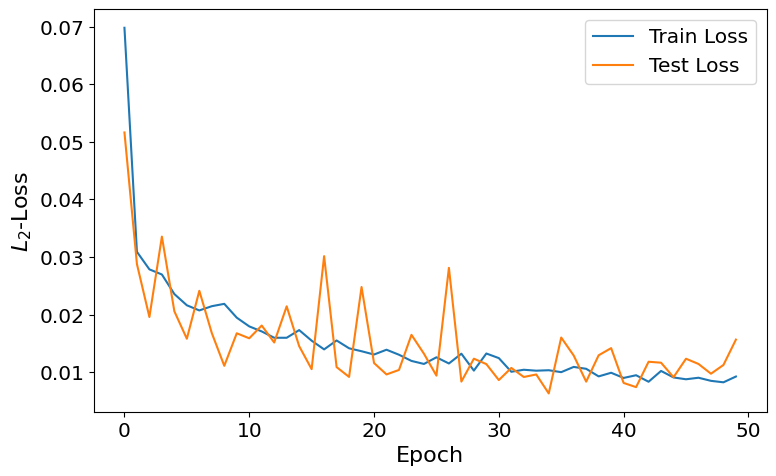

In [30]:
# Set global font sizes
plt.rcParams.update({
    'font.size': 14.5,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14.5,
    'ytick.labelsize': 14.5,
    'legend.fontsize': 14.5,
    'figure.titlesize': 20
})

plot_losses(train_losses, test_losses)

In [31]:
train_idx = np.random.randint(0, N_total)
test_idx = np.random.randint(0, test_ratio*N_total)

In [33]:
c_train_true = train_cn_anode[train_idx]
c_train_pred = model.apply(params,X_train[train_idx][None,...])

c_test_true = test_cn_anode[test_idx]
c_test_pred = model.apply(params,X_test[test_idx][None,...])


# Predicted concentration has shape (1,24,85,1)
# Slice out the original domain: [2:22, 5:80]
c_train_true_reshaped = c_train_true  # already (20,75)
c_test_true_reshaped = c_test_true   # already (20,75)
c_train_pred_reshaped = remove_padding(c_train_pred, padding_r, padding_t)
c_test_pred_reshaped = remove_padding(c_test_pred, padding_r, padding_t)

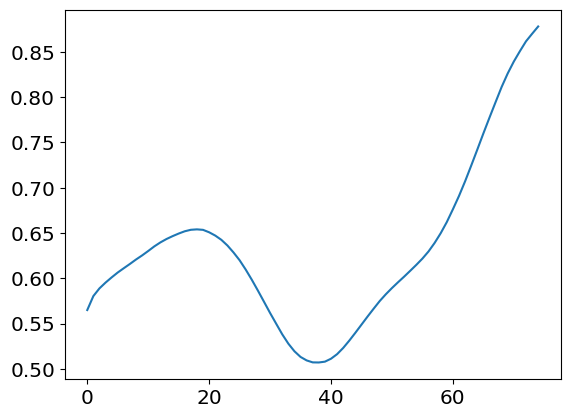

In [34]:
c_train_pred_reshaped = jnp.squeeze(c_train_pred_reshaped, axis=(0,-1))  # (20,75)
c_test_pred_reshaped = jnp.squeeze(c_test_pred_reshaped, axis=(0,-1))  # (20,75)

In [35]:
c_max = params_bat["Maximum concentration in negative electrode [mol.m-3]"]

In [36]:
c_train_pred_scaled = c_train_pred_reshaped * c_max
c_test_pred_scaled = c_test_pred_reshaped * c_max

c_test_true_scaled = c_test_true * c_max
c_train_true_scaled = c_train_true * c_max


In [37]:
fig, axs = create_plot_FNO_results(c_train_pred_scaled, c_train_true_scaled, c_test_pred_scaled, c_test_true_scaled,
                     train_I[train_idx], test_I[test_idx], t_max, Ran)

plt.show()

In [38]:
filename = functions.save_model_params(params, directory = "../trained_models/fno", family = family)

(20, 75)

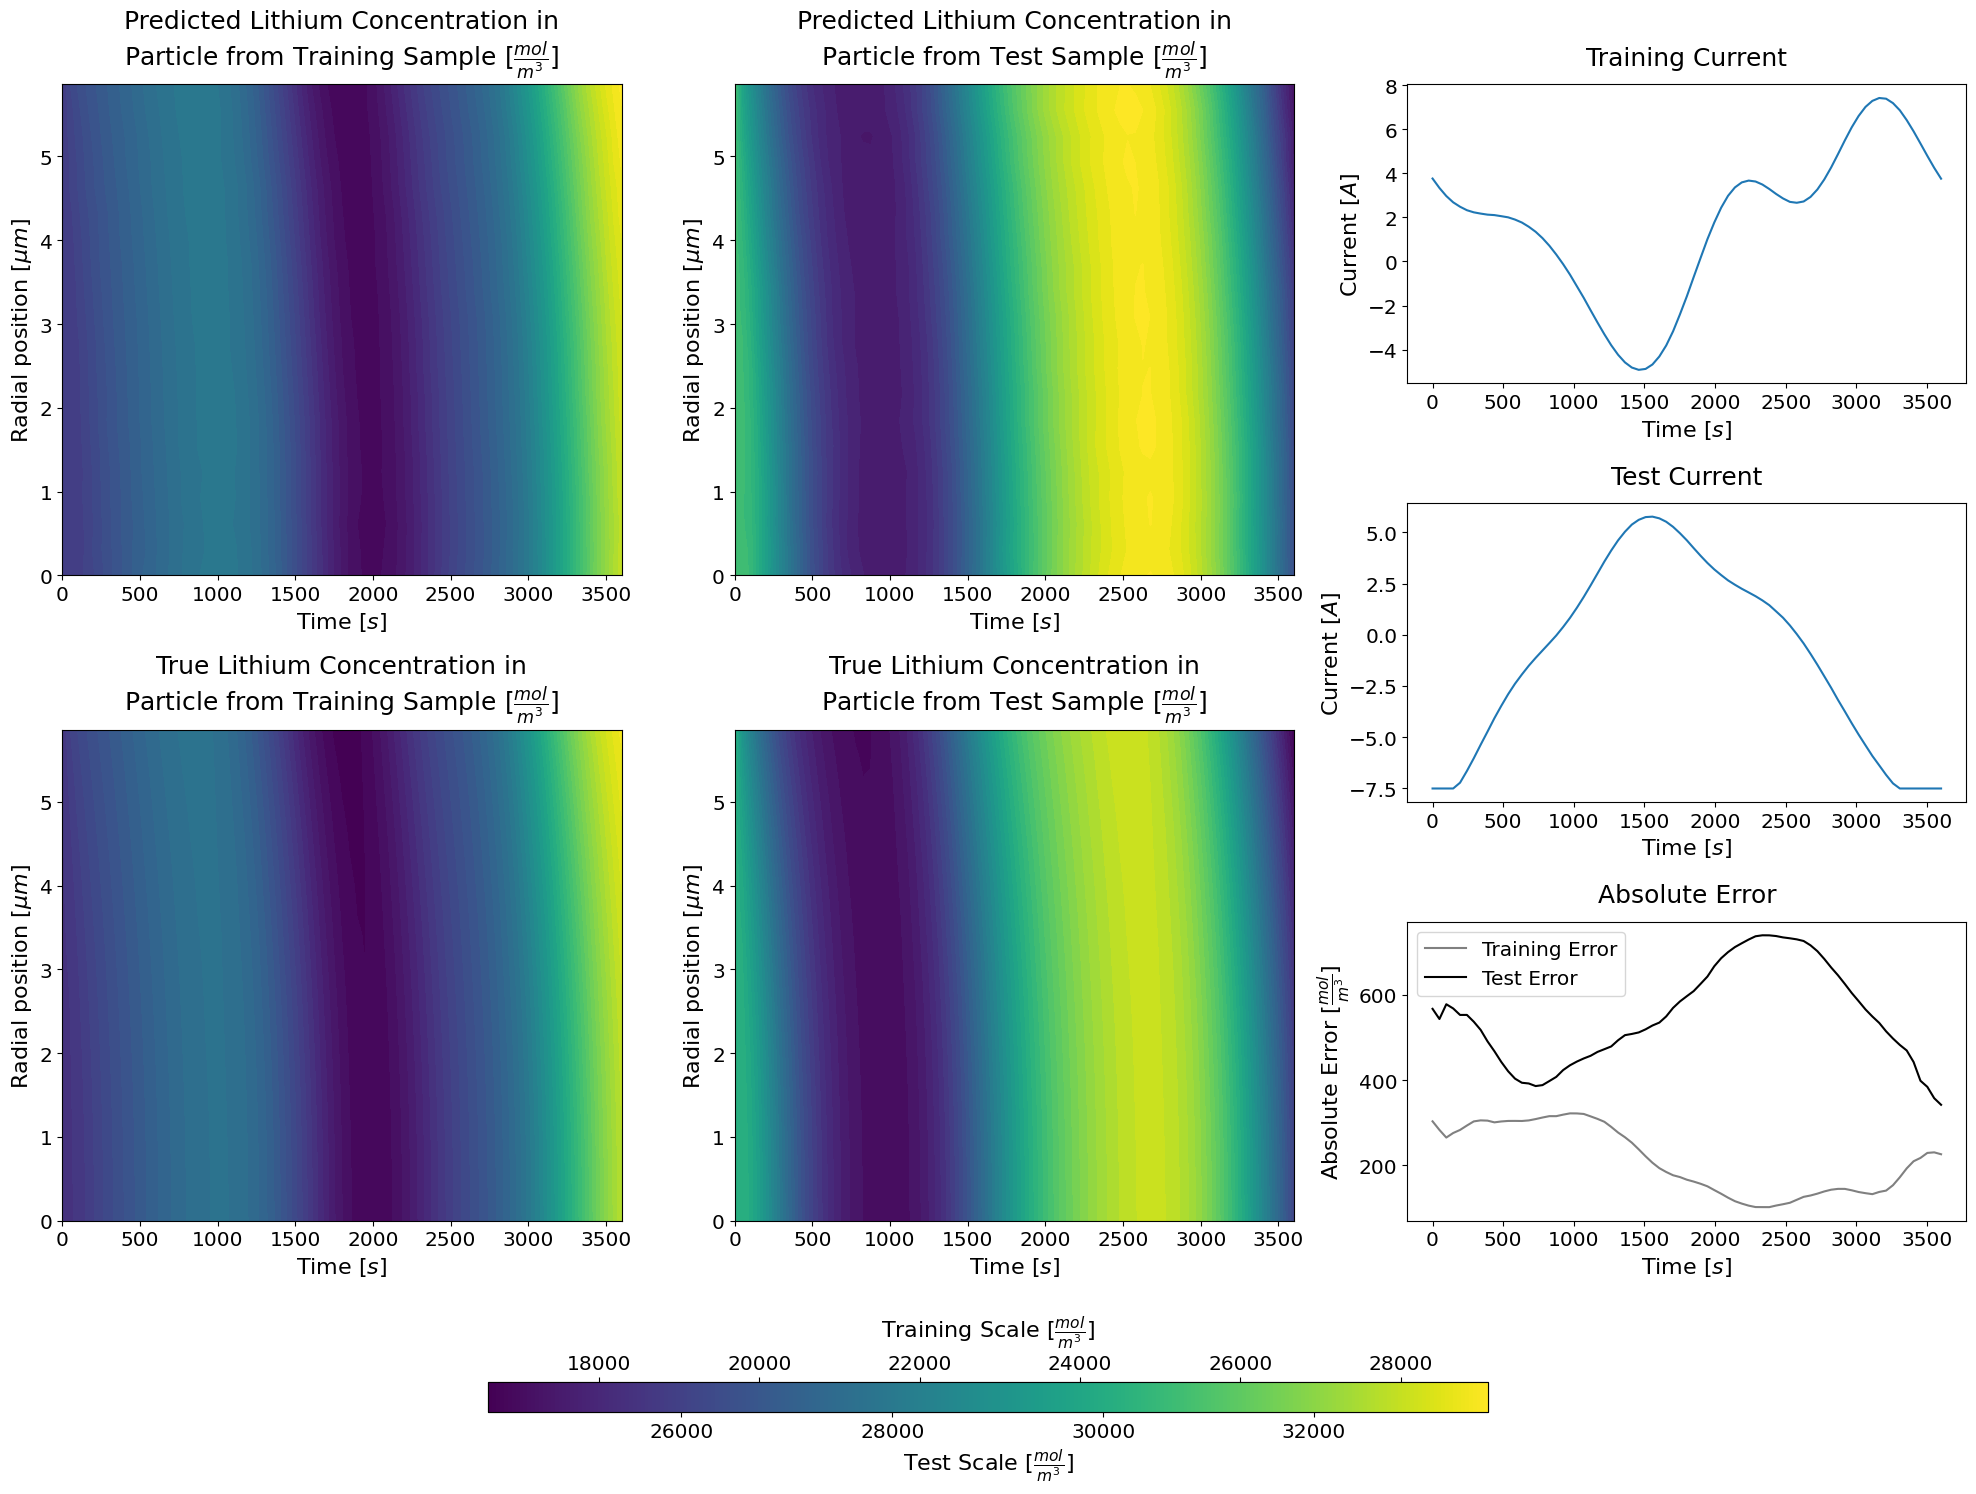

In [39]:
import gc
# del model
# del params
del X_train, Y_train, X_test, Y_test

#jax.clear_compilation_cache()
gc.collect()


In [40]:
X_train, Y_train = preprocess_data(train_I, train_c0_cathode, train_cn_cathode, num_samples_I, num_samples_c0, padding_r, padding_t)
X_test, Y_test = preprocess_data(test_I, test_c0_cathode, test_cn_cathode, num_samples_I, num_samples_c0, padding_r, padding_t)

Array([0.55690616, 0.55690616, 0.55690616, 0.55690616, 0.55690616,
       0.55690616, 0.55690616, 0.55690616, 0.55690616, 0.55690616,
       0.55690616, 0.55690616, 0.55690616, 0.55690616, 0.55690616,
       0.55690616, 0.55690616, 0.55690616, 0.55690616, 0.55690616],      dtype=float32)

In [41]:

model = FNO(k_modes=k_modes, fno_depth=fno_depth, hidden_channels=hidden_channels, output_channels=output_channels)

# Initialize parameters
init_key = jax.random.PRNGKey(42)
params = model.init(init_key, X_train[:1,...])

# Forward pass
out = model.apply(params, X_train[:1,...])
print("Output shape:", out.shape)  # should be (1,24,85,1)


Array([0.9106121, 0.9106121, 0.9106121, 0.9106121, 0.9106121, 0.9106121,
       0.9106121, 0.9106121, 0.9106121, 0.9106121, 0.9106121, 0.9106121,
       0.9106121, 0.9106121, 0.9106121, 0.9106121, 0.9106121, 0.9106121,
       0.9106121, 0.9106121], dtype=float32)

In [ ]:
pbar = trange(num_epochs, desc="Training")

train_losses = []
test_losses = []

for epoch in pbar:

    total_train_loss = 0.0
    count = 0

    for X_batch, Y_batch in data_loader(X_train, Y_train, batch_size):
        params, opt_state, loss_value = train_step(params, opt_state, jnp.array(X_batch), jnp.array(Y_batch))
        total_train_loss += loss_value
        count += 1

    total_test_loss = 0.0
    count2 = 0

    for X_batch, Y_batch in data_loader(X_test, Y_test, 200):
        loss_value = loss_fn(params, jnp.array(X_batch), jnp.array(Y_batch))
        total_test_loss += loss_value
        count2 += 1


    # train_losses.append(total_train_loss)
    # test_losses.append(total_test_loss)

    avg_train_loss = total_train_loss / count
    avg_test_loss = total_test_loss / count2

    train_losses.append(avg_train_loss)
    test_losses.append(avg_test_loss)

    desc_str = f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}"
    pbar.set_description_str(desc_str)

In [ ]:
filename = functions.save_model_params(params, directory = "../trained_models/fno", prefix = "cathode", family = family)

In [ ]:
# Set global font sizes
plt.rcParams.update({
    'font.size': 14.5,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14.5,
    'ytick.labelsize': 14.5,
    'legend.fontsize': 14.5,
    'figure.titlesize': 20
})

plot_losses(train_losses, test_losses)

In [ ]:
c_train_true = train_cn_cathode[train_idx]
c_train_pred = model.apply(params,X_train[train_idx][None,...])

c_test_true = test_cn_cathode[test_idx]
c_test_pred = model.apply(params,X_test[test_idx][None,...])


# Predicted concentration has shape (1,24,85,1)
# Slice out the original domain: [2:22, 5:80]
c_train_true_reshaped = c_train_true  # already (20,75)
c_test_true_reshaped = c_test_true   # already (20,75)
c_train_pred_reshaped = remove_padding(c_train_pred, padding_r, padding_t)
c_test_pred_reshaped = remove_padding(c_test_pred, padding_r, padding_t)

In [ ]:
c_train_pred_reshaped = jnp.squeeze(c_train_pred_reshaped, axis=(0,-1))  # (20,75)
c_test_pred_reshaped = jnp.squeeze(c_test_pred_reshaped, axis=(0,-1))  # (20,75)

In [ ]:
c_max = params_bat["Maximum concentration in positive electrode [mol.m-3]"]

In [ ]:
c_train_pred_scaled = c_train_pred_reshaped * c_max
c_test_pred_scaled = c_test_pred_reshaped * c_max

c_test_true_scaled = c_test_true * c_max
c_train_true_scaled = c_train_true * c_max

In [ ]:
fig, axs = create_plot_FNO_results(c_train_pred_scaled, c_train_true_scaled, c_test_pred_scaled, c_test_true_scaled,
                     train_I[train_idx], test_I[test_idx], t_max, Rca)

plt.show()